Plot 1 shows small step sizes like h = 0.01 match the exact solution well, while larger ones blow up.

Plot 2 shows average error increasing with h, which is expected since Euler’s method is first order. Larger steps make the approximation worse.

Plot 3 shows local error increasing with h near when x is 15.

For stability, lambda(x) = -2·cos(x) varies between -2 and 2. The condition |1 + hlambda| is less than or equal to 1 gives h is less than or equal to 1 in the worst case, but when cos(x) is negative, lambda is positive and the method becomes unstable for any h.

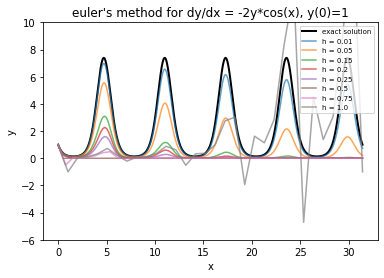

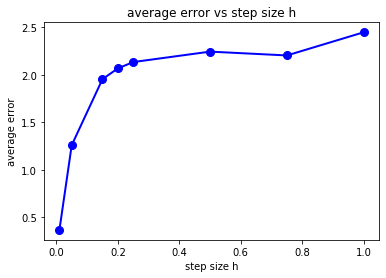

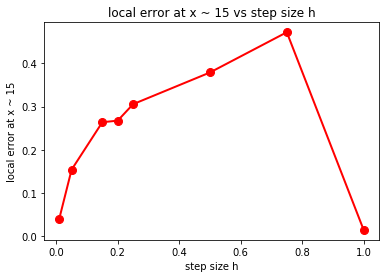

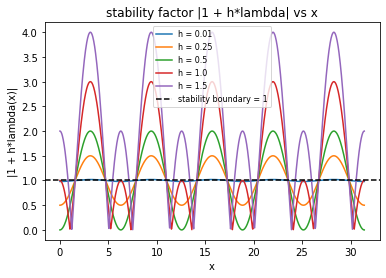

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# ode
def f(x, y):
    return -2 * y * np.cos(x)

# exact solution
def exact(x):
    return np.exp(-2 * np.sin(x))

# euler's method
def euler(h, x_start, x_end):
    n = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_end, n + 1)
    y = np.zeros(n + 1)
    y[0] = 1
    for i in range(n):
        y[i+1] = y[i] + h * f(x[i], y[i])
    return x, y

x_start = 0
x_end = 10 * np.pi

# step sizes
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]

# euler's method for each h
x_exact = np.linspace(x_start, x_end, 10000)
plt.plot(x_exact, exact(x_exact), 'k-', linewidth=2, label='exact solution')

for h in h_values:
    x, y = euler(h, x_start, x_end)
    plt.plot(x, y, label=f'h = {h}', alpha=0.7)

plt.xlabel('x')
plt.ylabel('y')
plt.title("euler's method for dy/dx = -2y*cos(x), y(0)=1")
plt.legend(loc='upper right', fontsize=7)
plt.ylim(-6, 10)
plt.show()

# average error vs h
avg_errors = []

for h in h_values:
    x, y_euler = euler(h, x_start, x_end)
    y_true = exact(x)
    avg_err = np.mean(np.abs(y_euler - y_true))
    avg_errors.append(avg_err)

plt.plot(h_values, avg_errors, 'bo-', linewidth=2, markersize=8)
plt.xlabel('step size h')
plt.ylabel('average error')
plt.title('average error vs step size h')
plt.show()

local_errors_at_15 = []

for h in h_values:
    x, y_euler = euler(h, x_start, x_end)
    idx = np.argmin(np.abs(x - 15))
    x_near = x[idx]
    y_approx = y_euler[idx]
    y_true = exact(x_near)
    local_err = np.abs(y_approx - y_true)
    local_errors_at_15.append(local_err)

plt.plot(h_values, local_errors_at_15, 'ro-', linewidth=2, markersize=8)
plt.xlabel('step size h')
plt.ylabel('local error at x ~ 15')
plt.title('local error at x ~ 15 vs step size h')
plt.show()

# addendum
x_check = np.linspace(0, 10 * np.pi, 1000)
for h in [0.01, 0.25, 0.5, 1.0, 1.5]:
    lam = -2 * np.cos(x_check)
    growth = np.abs(1 + h * lam)
    plt.plot(x_check, growth, label=f'h = {h}')
plt.axhline(y=1, color='k', linestyle='--', label='stability boundary = 1')
plt.xlabel('x')
plt.ylabel('|1 + h*lambda(x)|')
plt.title('stability factor |1 + h*lambda| vs x')
plt.legend(fontsize=8)
plt.show()